# Exercice 03 – Faire converser deux modèles

## Objectif

Deux modèles différents, servis par **deux `llama-server` en parallèle** sur le même GPU, tiennent une conversation l'un avec l'autre sur un sujet que vous choisissez. Vous enregistrez chaque tour avec ses métriques, puis vous analysez le résultat.

C'est un exercice récapitulatif : tout ce que vous avez vu (build, options du serveur, VRAM, rôles, historique, `usage`, `timings`, polars) est mobilisé.

## Ce que vous devez livrer

1. **Un plan VRAM** (section 1) : quels modèles, quelles quantisations, quel contexte pour chacun, et pourquoi ça tient dans 24 Go.
2. **Les deux commandes de lancement** des serveurs.
3. **Le code** de la conversation, avec collecte des métriques à chaque tour.
4. **Un CSV** des tours et **au moins deux graphiques**.
5. **Une analyse** écrite (section 6).

## Contraintes

- Deux modèles **différents** (famille, taille ou quantisation).
- Chaque modèle a un **system prompt** qui lui donne un rôle et un **objectif** dans la conversation.
- Nombre de tours maximal fixé à l'avance (10 à 20).
- Métriques par tour : au minimum `prompt_tokens`, `completion_tokens`, `prompt_n` (tokens réellement traités), `tok/s`, durée, VRAM utilisée.

## Idées de sujets

- Un débat contradictoire (pour / contre une idée) avec un modérateur imaginaire
- Une négociation : vendeur et acheteur d'un objet, chacun avec un prix cible secret
- Un professeur et un élève qui ne comprend pas une notion
- Le jeu « qui suis-je ? » : l'un pense à un personnage, l'autre pose des questions fermées
- Deux personnages de fiction qui se rencontrent

> Sans objectif clair dans les system prompts, la conversation tourne en politesses au bout de 5 tours. Ce n'est pas grave : c'est un résultat d'analyse en soi.

In [1]:
import subprocess
import time

import matplotlib.pyplot as plt
import polars as pl
import requests
from openai import OpenAI

## Section 1 – Plan VRAM

Avant de lancer quoi que ce soit, remplissez ce tableau. La VRAM d'un modèle chargé = **poids** + **KV cache** + un peu de marge (buffers de calcul).

Ordres de grandeur : un 8B en Q4_K_M pèse ~5 Go, un 4B en Q4_K_M ~2,5 Go. Le KV cache dépend du modèle et du contexte ; à `-c 8192` comptez 1 à 2 Go pour un 8B avec flash attention.

| | Modèle A | Modèle B |
|---|---|---|
| Fichier GGUF |gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf | Qwen3.5-9B-UD-Q4_K_XL.gguf|
| Taille du fichier (Go) |17 | 6|
| `-c` choisi | 16384| 16384|
| VRAM estimée |18-19 |7-9 |
| Port | 8080 | 8081 |


Total estimé : _~26Go__ Go sur 24 Go.

> **Tips**
> - `ls -lh *.gguf` pour la taille des fichiers.
> - Pour vérifier après lancement : `nvidia-smi --query-gpu=memory.used --format=csv`.
> - Si ça ne tient pas : baissez `-c`, ou prenez une quantisation plus petite. Notez ce que vous avez changé.
> - Bonus : lisez `n_layer`, `n_head_kv` et `key_length` dans les métadonnées du GGUF (paquet `gguf`) et calculez le KV cache exactement : `2 × n_layer × n_ctx × n_head_kv × key_length × 2 octets`.

## Section 2 – Lancer les deux serveurs

Deux terminaux, deux ports. Complétez :

```bash
# Terminal 1
llama-server -m ______ -c ____ -np 1 -fa on -ngl 99 --port 8080

# Terminal 2
llama-server -m ______ -c ____ -np 1 -fa on -ngl 99 --port 8081
```

> **Tips**
> - Lancez-les **l'un après l'autre** et regardez `nvidia-smi` entre les deux.
> - Le second peut échouer avec une erreur CUDA « out of memory » si le plan VRAM est trop optimiste. C'est le moment d'ajuster.
> - Alternative : lancer les serveurs depuis le notebook avec `subprocess.Popen([...])`, puis attendre que `/health` réponde `ok` avant de continuer.

In [2]:
# llama-server -m ~/models/qwen3.5-9b/llama/Qwen3.5-9B-UD-Q4_K_XL.gguf -ngl 33 -np 1 -c 16384 --port 8080 --host 127.0.0.1

# llama-server -m ~/models/gemma4-26b-a4b/llama/gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf -np 1 -c 16384 --port 8081 --host 127.0.0.1

# bm@bm-HP-Z4-G4-Workstation:~/formation/formation/vLLM/01_open_ai_api$ nvidia-smi --query-gpu=memory.used --format=csv
# memory.used [MiB]
# 22823 MiB


In [3]:
URL_A = "http://127.0.0.1:8080"
URL_B = "http://127.0.0.1:8081"

client_A = OpenAI(base_url=f"{URL_A}/v1", api_key="pas-besoin")
client_B = OpenAI(base_url=f"{URL_B}/v1", api_key="pas-besoin")

NOM_A = "modele_Qwen3.8-27B-UD-Q4_K_XL"   # à remplacer par un nom parlant
NOM_B = "modele_gemma-4-26B-A4B-it-UD-Q4_K_XL"

for url in (URL_A, URL_B):
    print(url, requests.get(f"{url}/health").json())

http://127.0.0.1:8080 {'status': 'ok'}
http://127.0.0.1:8081 {'status': 'ok'}


## Section 3 – Mesurer la VRAM depuis Python

Écrivez `vram_utilisee_mb() -> int` qui appelle `nvidia-smi` via `subprocess` et renvoie la mémoire utilisée en Mo.

> **Tip** : `nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits` renvoie juste un nombre. `subprocess.check_output([...], text=True)` récupère la sortie.

In [4]:
# def vram_utilisee_mb() -> int:
#     # TODO
    

# print(vram_utilisee_mb(), "Mo utilisés avec les deux serveurs chargés")

In [5]:
import subprocess

def vram_utilisee_mb() -> int:
    resultat = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
        text=True
    )
    return int(resultat.strip())

print(vram_utilisee_mb(), "Mo utilisés avec les deux serveurs chargés")

23003 Mo utilisés avec les deux serveurs chargés


## Section 4 – La conversation

### Le piège des rôles

Chaque modèle a **son propre historique**. Ce que A dit est `assistant` dans l'historique de A, mais `user` dans celui de B. Et inversement. Faites un schéma avant de coder si besoin.

### À écrire

1. Deux system prompts : `SYSTEM_A`, `SYSTEM_B`, avec un rôle et un objectif chacun.
2. Un **message d'amorce** que A recevra comme premier message `user` (par exemple « Bonjour, commençons. »).
3. Une fonction `tour(client, history, message) -> tuple[str, dict]` qui ajoute `message` en `user`, appelle le modèle, ajoute la réponse en `assistant`, et renvoie la réponse et un dictionnaire de métriques (`prompt_tokens`, `completion_tokens`, `prompt_n`, `tok_par_s`, `duree_ms`, `finish_reason`).
4. La boucle principale : `N_TOURS` fois, A parle puis B parle. Le message de l'un devient l'entrée de l'autre. À chaque tour, ajoutez à une liste `journal` un dictionnaire avec le numéro de tour, le nom du modèle, les métriques, la VRAM et le texte.
5. Affichez la conversation au fur et à mesure.

> **Tips**
> - `max_tokens=250` évite les monologues et garde la conversation lisible.
> - `temperature=0.7` : une conversation à `temperature=0` est vite répétitive.
> - Pensez à désactiver le mode think de Qwen3 (`extra_body={"chat_template_kwargs": {"enable_thinking": False}}`), sinon les tours sont très lents.
> - `prompt_n` est dans `timings`, pas dans `usage`. C'est le nombre de tokens **réellement recalculés** grâce au cache.

In [6]:
SYSTEM_A = """TODO"""
SYSTEM_B = """TODO"""
AMORCE = "Bonjour, commençons."
N_TOURS = 10

def tour(client, history: list, message: str) -> tuple[str, dict]:
    # TODO
    ...

history_A = [{"role": "system", "content": SYSTEM_A}]
history_B = [{"role": "system", "content": SYSTEM_B}]
journal = []

# TODO : boucle principale

In [14]:
# ============================================================
# CONVERSATION + SYNTHÈSES A ET B
# ============================================================

from IPython.display import display, HTML
import html


def faire_synthese(client, journal):

    conversation = "\n\n".join(
        f"Tour {x['tour']} — Modèle {x['modele']}:\n{x['texte']}"
        for x in journal
    )

    prompt = f"""
Analyse cette conversation entre deux modèles.

Donne une synthèse courte et structurée :

1. Sujets principaux
2. Arguments du modèle A
3. Arguments du modèle B
4. Points d'accord
5. Désaccords
6. Évolution de la discussion
7. Répétitions
8. Conclusion

Base-toi uniquement sur la conversation.

CONVERSATION :

{conversation}
"""

    r = client.chat.completions.create(
        model="local-model",
        messages=[
            {"role": "user", "content": prompt}
        ],
        max_tokens=1200,
        temperature=0.2,

        # IMPORTANT POUR QWEN
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    return r.choices[0].message.content or "[AUCUN TEXTE PRODUIT]"


# Synthèse par les deux modèles
synthese_A = faire_synthese(client_A, journal)
synthese_B = faire_synthese(client_B, journal)


# Conversation complète
conversation_html = "<br><br>".join(
    f"<b>Tour {x['tour']} — Modèle {x['modele']}</b><br>{html.escape(x['texte'])}"
    for x in journal
)


# Affichage sur UN écran
display(HTML(f"""
<div style="display:grid;
            grid-template-columns: 1.5fr 1fr;
            gap:20px;
            height:800px;">

    <div style="overflow-y:auto;
                border:1px solid #777;
                padding:15px;">

        <h2>Conversation complète</h2>

        {conversation_html}

    </div>


    <div style="overflow-y:auto;
                border:1px solid #777;
                padding:15px;">

        <h2>Synthèse modèle A</h2>

        <pre style="white-space:pre-wrap;">
{html.escape(synthese_A)}
        </pre>

        <hr>

        <h2>Synthèse modèle B</h2>

        <pre style="white-space:pre-wrap;">
{html.escape(synthese_B)}
        </pre>

    </div>

</div>
"""))

## Section 5 – Sauvegarde et graphiques

1. `pl.DataFrame(journal)` → `conversation.csv` (`write_csv`).
2. Graphique 1 : `prompt_tokens` en fonction du tour, une courbe par modèle. Ajoutez une ligne horizontale pour le `-c` de chaque modèle.
3. Graphique 2 : `completion_tokens` par tour et par modèle (les réponses raccourcissent-elles ? s'allongent-elles ?).
4. Graphique 3 : `tok_par_s` par modèle.
5. Bonus : `prompt_tokens` vs `prompt_n` sur le même graphique pour visualiser l'effet du cache.

> **Tip** : `df.pivot(on="modele", index="tour", values="prompt_tokens")` donne une colonne par modèle. Il ne reste qu'à tracer chaque colonne avec `plt.plot(large["tour"], large[nom], label=nom)`.

(54, 10)
conversation.csv sauvegardé


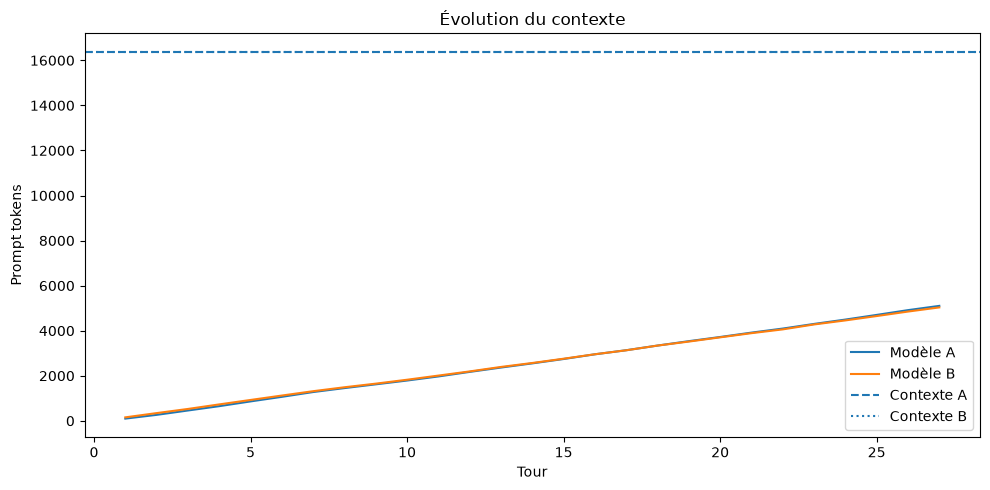

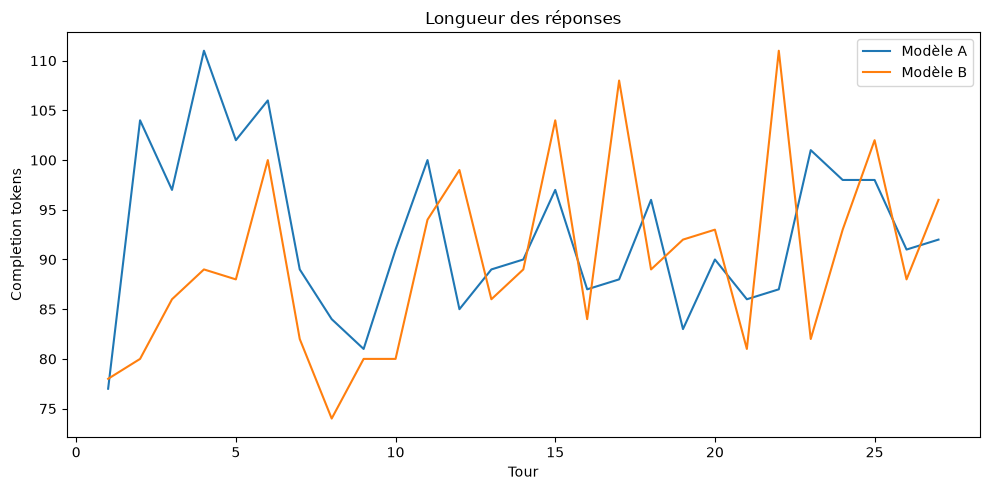

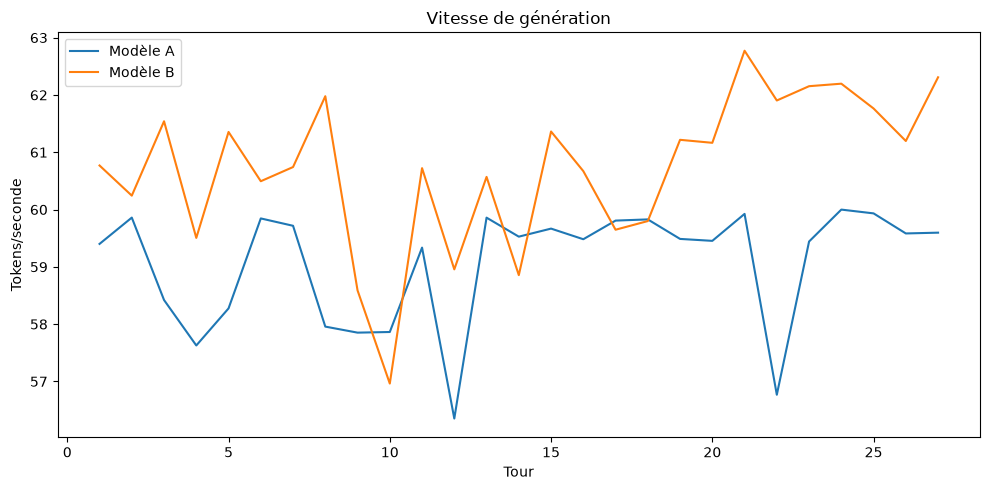

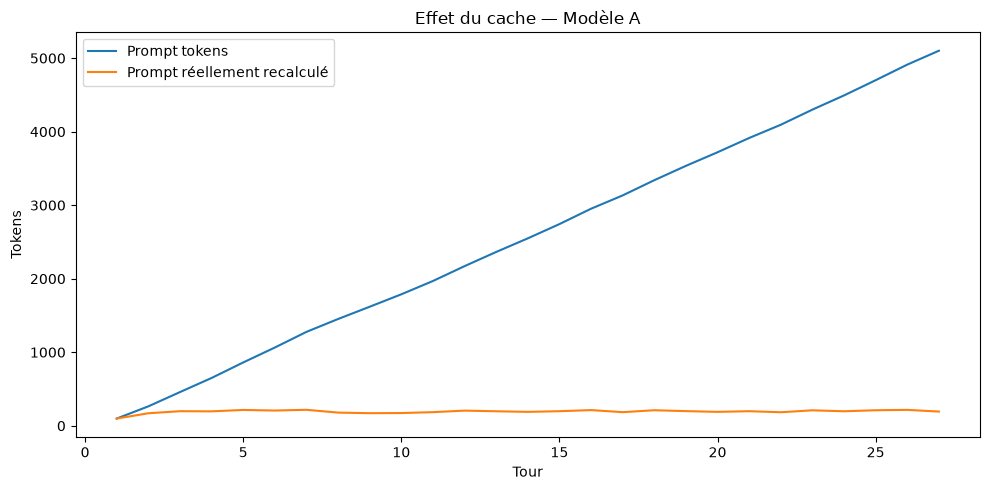

In [21]:
# TODO

# ============================================================
# SECTION 5 — SAUVEGARDE ET GRAPHIQUES
# ============================================================

import polars as pl
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. CONVERSION DU JOURNAL EN DATAFRAME + CSV
# ------------------------------------------------------------

# Transforme la liste de dictionnaires "journal" en DataFrame Polars.
df = pl.DataFrame(journal)

# Sauvegarde toutes les données de l'expérience dans un fichier CSV.
df.write_csv("conversation.csv")

# Vérification rapide.
print(df.shape)
print("conversation.csv sauvegardé")


# ------------------------------------------------------------
# 2. GRAPHIQUE : PROMPT TOKENS
# ------------------------------------------------------------

# Transforme les lignes A/B en deux colonnes séparées.
large = df.pivot(
    on="modele",               # crée une colonne par modèle
    index="tour",              # axe X = numéro du tour
    values="prompt_tokens"     # valeur représentée
).sort("tour")

# Contextes configurés avec -c dans llama-server.
CONTEXTE_A = 16384
CONTEXTE_B = 16384

plt.figure(figsize=(10, 5))

# Courbe du modèle A.
plt.plot(large["tour"], large["A"], label="Modèle A")

# Courbe du modèle B.
plt.plot(large["tour"], large["B"], label="Modèle B")

# Limite du contexte A.
plt.axhline(CONTEXTE_A, linestyle="--", label="Contexte A")

# Limite du contexte B.
plt.axhline(CONTEXTE_B, linestyle=":", label="Contexte B")

plt.xlabel("Tour")
plt.ylabel("Prompt tokens")
plt.title("Évolution du contexte")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. GRAPHIQUE : COMPLETION TOKENS
# ------------------------------------------------------------

large_completion = df.pivot(
    on="modele",
    index="tour",
    values="completion_tokens"
).sort("tour")

plt.figure(figsize=(10, 5))

plt.plot(
    large_completion["tour"],
    large_completion["A"],
    label="Modèle A"
)

plt.plot(
    large_completion["tour"],
    large_completion["B"],
    label="Modèle B"
)

plt.xlabel("Tour")
plt.ylabel("Completion tokens")
plt.title("Longueur des réponses")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. GRAPHIQUE : TOKENS PAR SECONDE
# ------------------------------------------------------------

large_speed = df.pivot(
    on="modele",
    index="tour",
    values="tok_par_s"
).sort("tour")

plt.figure(figsize=(10, 5))

plt.plot(
    large_speed["tour"],
    large_speed["A"],
    label="Modèle A"
)

plt.plot(
    large_speed["tour"],
    large_speed["B"],
    label="Modèle B"
)

plt.xlabel("Tour")
plt.ylabel("Tokens/seconde")
plt.title("Vitesse de génération")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. BONUS : PROMPT_TOKENS VS PROMPT_N
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

# On filtre ici le modèle A pour rendre le graphique lisible.
df_A = df.filter(pl.col("modele") == "A")

plt.plot(
    df_A["tour"],
    df_A["prompt_tokens"],
    label="Prompt tokens"
)

plt.plot(
    df_A["tour"],
    df_A["prompt_n"],
    label="Prompt réellement recalculé"
)

plt.xlabel("Tour")
plt.ylabel("Tokens")
plt.title("Effet du cache — Modèle A")
plt.legend()
plt.tight_layout()
plt.show()

## Section 6 – Analyse

Répondez ici, en vous appuyant sur vos graphiques :

1. Lequel des deux modèles aurait atteint sa limite de contexte le premier si la conversation avait continué ? Pourquoi (taille de `-c`, verbosité, tokenizer) ?
2. La conversation a-t-elle atteint l'objectif fixé dans les system prompts ? À quel tour a-t-elle commencé à dégénérer, si c'est le cas ?
3. Comparez `prompt_tokens` et `prompt_n` : combien de tokens le cache a-t-il économisés au total ?
4. Le modèle le plus rapide en tok/s est-il celui que vous attendiez ? Le fait de partager le GPU avec un autre serveur a-t-il un effet visible ?
5. Qu'auriez-vous fait différemment dans le plan VRAM avec le recul ?

*Vos réponses ici…*

## Bonus

- Ajoutez un **troisième appel** en fin de conversation qui demande à l'un des modèles de résumer l'échange et de dire qui a « gagné ».
- Faites tourner la même conversation en remplaçant le modèle B par une autre quantisation du modèle A. La conversation est-elle différente ?
- Utilisez `-np 2` sur **un seul** serveur avec un seul modèle et deux system prompts différents. Comparez la VRAM avec la version deux serveurs. Quand cette approche est-elle préférable ?